# Proyecto 1 - Simple_ImgProcessing

## Equipo: 22

## Integrantes
 - Erick Alan Cuéllar Quintanilla
 - Fanny Betsabé Fuentes Reyes
 - David Felipe Hernández Chiapa
 - José Emmanuel Vázquez Galán

In [1]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [2]:
def img_to_np_array(img_path):
    img = Image.open(img_path)
    return np.array(img)

def show_image(img_array):
    if img_array.ndim == 2:
        plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img_array)
    plt.axis("off")
    plt.show()

## Cargar y mostrar imagenes 

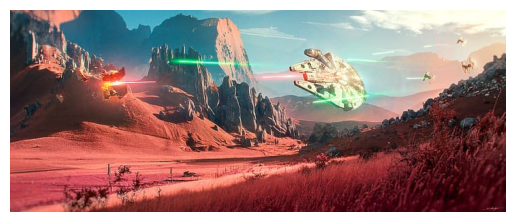

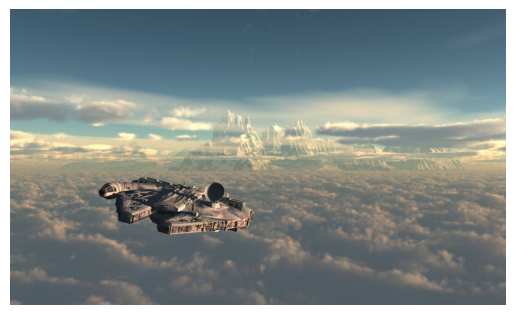

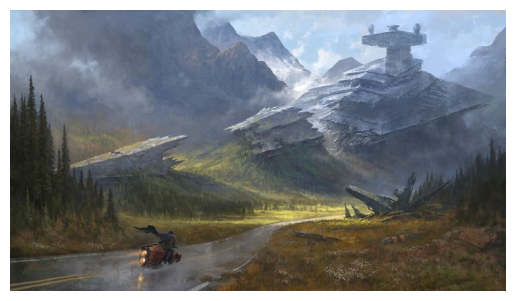

In [3]:
img1_array = img_to_np_array('data/img1.jpg')
img2_array = img_to_np_array('data/img2.jpg')
img3_array = img_to_np_array('data/img3.jpg')
img4_array = img_to_np_array('data/space.webp')
img5_array = img_to_np_array('data/gamma_c.jpg')
img6_1_array = img_to_np_array('data/img6_1.png')
img6_2_array = img_to_np_array('data/img6_2.png')

show_image(img1_array)
show_image(img2_array)
show_image(img3_array)



### Pregunta 1

Las transformaciones píxel a píxel son sumamente utilizadas para aumentar la cantidad de imágenes para entrenar modelos de inteligencia artificial, sobre todo aquellas de tipo fotométrico. Investiga 3 tipos de transformaciones y aplícalas en el proyecto de Google Colab sobre imágenes propias.

#### Respuesta

Existen varios tipos de transformaciones fotométricas píxel a píxel, como la inversión, la corrección de gamma, el ajuste de brillo y la binarización. Estas técnicas se utilizan para aumentar los datos al entrenar modelos de inteligencia artificial, ya que, al introducir variación en una misma imagen, se busca que el modelo esté acostumbrado a ver la misma forma con distintos colores. Esto es importante porque, en la realidad, debido a las luces, sombras y reflejos, los colores pueden cambiar; se busca evitar que los modelos se sobreentrenen.

En este caso, usaremos la corrección de gamma, la inversión y la binarización.

In [4]:
# Funciones

def gamma_correction(img_array, gamma, c):
    # normalizando
    img_normalized = img_array / 255.0
    # aplicando corrección gamma
    img_corrected = c * np.power(img_normalized, gamma)
    # escalando de nuevo a 0-255
    return np.uint8(img_corrected * 255)

def invert_image(img_array):
    return 255 - img_array

def color_to_b_and_w(img_array):
    return np.mean(img_array, axis=2)

def binarization(img_array, threshold):
    return np.where(img_array > threshold, 255, 0)

##### Correccion de gamma.

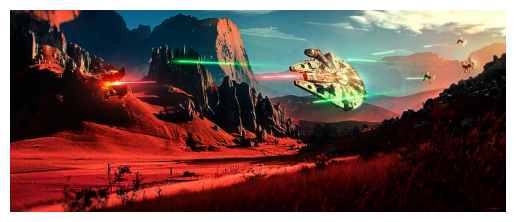

In [5]:
show_image(gamma_correction(img1_array, gamma=2.2, c=1))

##### Inversion de imagen.

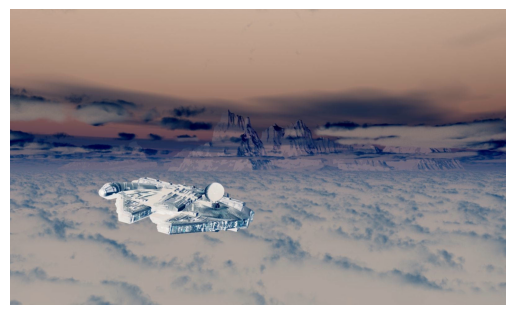

In [6]:
show_image(invert_image(img2_array))

##### Binarizacion

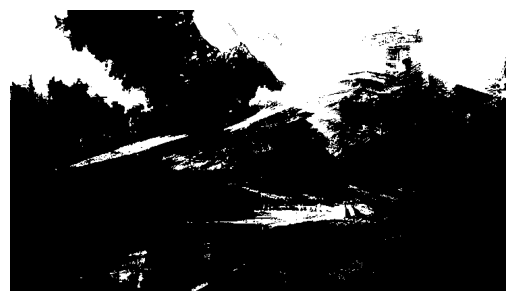

In [7]:
# First black and white image
bnw = color_to_b_and_w(img3_array)
# then binarize it
show_image(binarization(bnw, 127))

### Pregunta 2
Investiga una aplicación donde obtener el negativo de imagen tenga un valor específico e integra el código en en una fila de google collab, justificar brevemente tu investigación y haciendo una demo sencilla.

#### Respuesta
Una aplicaicion interesante de usar negativos es en la astronomia. Los cuerpos celestes lejanos son pequenios puntos grises en una gran imagen negra, el invertir el rango del fondo espacial hace mucho mas facil la tarea de indentificar estos cuerpos celestes para el ojo humano.

Referencia: Berry, R., & Burnell, J. (2005). The Handbook of Astronomical Image Processing. Willmann-Bell.

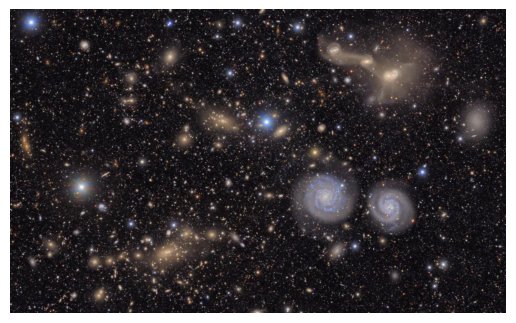

In [8]:
# Original image
show_image(img4_array)

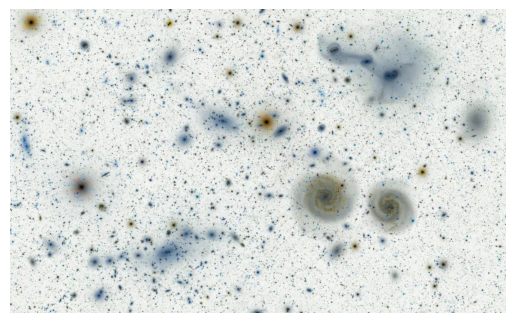

In [9]:
# Inverted
inverted_img4 = invert_image(img4_array)
show_image(inverted_img4)

### Pregunta 3
Investiga una aplicación donde se puede aplicar la corrección de gamma en una imagen. Integra el código en en una fila de google collab, justifica brevemente tu investigación y haz una demo sencilla.

#### Respuesta
En el area de vision artificial para conduccion autonoma. El uso de correccion de gamma es usado por algoritmos de vision artificial para identificacion de objetos en exteriores en condiciones de deslumbramientos o sombras imprevistas.

Referencia: Review of Gamma Correction Techniques in Digital Imaging Systems. (2024). ResearchGate Publications.

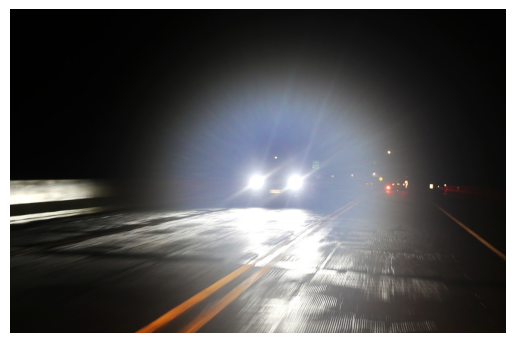

In [10]:
# Original
show_image(img5_array)

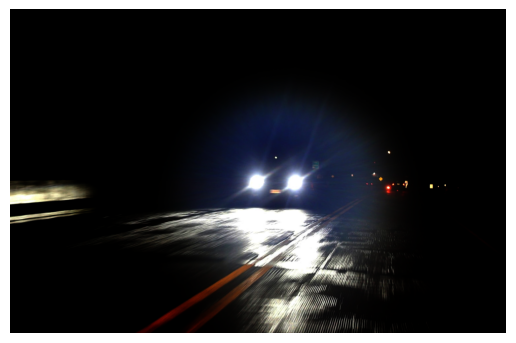

In [11]:
# Corrected
show_image(gamma_correction(img5_array, 4, 1))

### Pregunta 4
Investiga una aplicación donde se puede usar la sustracción de imágenes e integra el código en en una fila de google collab, justificar brevemente tu investigación, haciendo una demo sencilla.

#### Respuesta
En sistemas de videovigilancia se puede detectar el movimiento gracias a la sustraccion de las imagenes estaticas fotograma por fotograma. Si hay un cambio en el siguiente fotograma se resalta el objeto en movimiento inmediatamente.

Referncia: Radke, R. J., et al. (2005). Image change detection algorithms: a systematic survey. IEEE Transactions on Image Processing.

In [12]:
def img_sustraction(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError("Las imágenes deben tener las mismas dimensiones.")
    return cv2.absdiff(img1, img2)

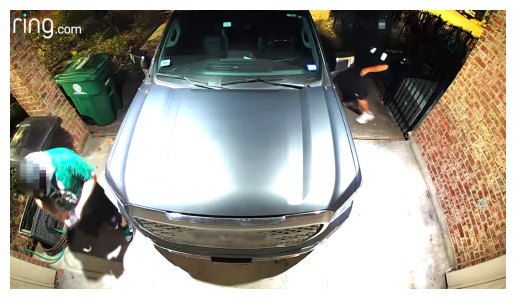

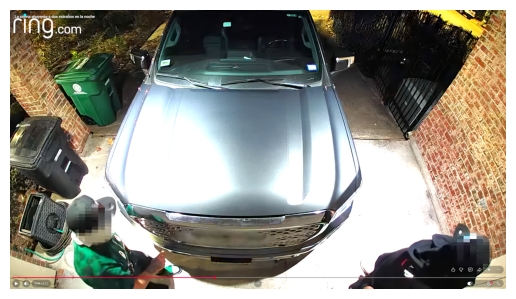

In [13]:
#Imagenes originales
show_image(img6_1_array)
show_image(img6_2_array)

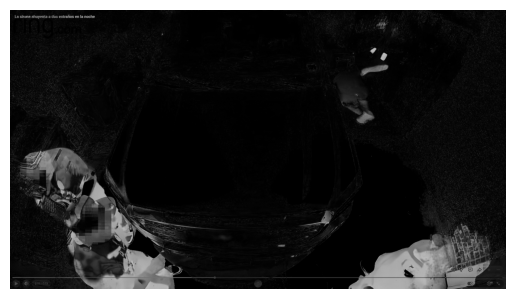

In [14]:
# Sustracción
difference = img_sustraction(img6_1_array, img6_2_array)
difference_b_and_w = color_to_b_and_w(difference)
show_image(difference_b_and_w)